# 06. Comparación computacional

Este cuaderno reúne los resultados finales de clasificación y regresión. No entrena modelos nuevos.

# Índice

1. Librerías utilizadas.
2. Carga de resultados.
3. Rankings finales.
4. Validación y búsqueda de hiperparámetros.
5. Matrices de confusión.
6. Figuras finales.
7. Guardado de resultados finales.

# 1. Librerías utilizadas

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 2. Carga de resultados

En este bloque se cargan los resultados generados en los cuadernos anteriores. En clasificación se utiliza el F1 positivo como métrica principal y el ROC-AUC como métrica complementaria. En regresión se utiliza el RMSE como métrica principal y el R² como métrica complementaria.

Además, se añade una variable de familia de modelo para distinguir entre CART, Bagging y Boosting, lo que facilita la comparación global y la interpretación posterior de los resultados.

In [2]:
ruta_tablas = "../../reports/tables/serie_computacional"
ruta_figuras = "../../reports/figures/serie_computacional"

os.makedirs(ruta_tablas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)

cart_clasificacion = pd.read_csv(f"{ruta_tablas}/cart_clasificacion_metricas.csv")
bagging_clasificacion = pd.read_csv(f"{ruta_tablas}/bagging_clasificacion_metricas.csv")
boosting_clasificacion = pd.read_csv(f"{ruta_tablas}/boosting_clasificacion_metricas.csv")

cart_regresion = pd.read_csv(f"{ruta_tablas}/cart_regresion_metricas.csv")
bagging_regresion = pd.read_csv(f"{ruta_tablas}/bagging_regresion_metricas.csv")
boosting_regresion = pd.read_csv(f"{ruta_tablas}/boosting_regresion_metricas.csv")

cart_clasificacion["familia_modelo"] = "CART"
bagging_clasificacion["familia_modelo"] = "Bagging"
boosting_clasificacion["familia_modelo"] = "Boosting"

cart_regresion["familia_modelo"] = "CART"
bagging_regresion["familia_modelo"] = "Bagging"
boosting_regresion["familia_modelo"] = "Boosting"

resultados_clasificacion = pd.concat(
    [
        cart_clasificacion,
        bagging_clasificacion,
        boosting_clasificacion,
    ],
    ignore_index=True,
    sort=False,
)

resultados_regresion = pd.concat(
    [
        cart_regresion,
        bagging_regresion,
        boosting_regresion,
    ],
    ignore_index=True,
    sort=False,
)

columnas_inicio_clasificacion = [
    "dataset",
    "escenario",
    "familia_modelo",
    "modelo",
    "indice_configuracion",
]

columnas_metricas_clasificacion = [
    "f1_positivo",
    "precision_positiva",
    "recall_positivo",
    "roc_auc",
    "accuracy",
]

columnas_inicio_regresion = [
    "dataset",
    "familia_modelo",
    "modelo",
    "indice_configuracion",
]

columnas_metricas_regresion = [
    "rmse",
    "mae",
    "mse",
    "r2",
]

resultados_clasificacion = resultados_clasificacion[
    columnas_inicio_clasificacion
    + columnas_metricas_clasificacion
    + [
        col for col in resultados_clasificacion.columns
        if col not in columnas_inicio_clasificacion + columnas_metricas_clasificacion
    ]
]

resultados_regresion = resultados_regresion[
    columnas_inicio_regresion
    + columnas_metricas_regresion
    + [
        col for col in resultados_regresion.columns
        if col not in columnas_inicio_regresion + columnas_metricas_regresion
    ]
]

assert len(resultados_clasificacion) == 9
assert len(resultados_regresion) == 9
assert resultados_clasificacion["modelo"].nunique() == 9
assert resultados_regresion["modelo"].nunique() == 9
assert set(resultados_clasificacion["escenario"]) == {"sin_duration"}
assert resultados_clasificacion["f1_positivo"].notna().all()
assert resultados_clasificacion["roc_auc"].notna().all()
assert resultados_regresion["rmse"].notna().all()
assert resultados_regresion["r2"].notna().all()

resumen_carga = pd.DataFrame([
    {
        "problema": "clasificación",
        "n_modelos": resultados_clasificacion["modelo"].nunique(),
        "n_familias": resultados_clasificacion["familia_modelo"].nunique(),
        "metrica_principal": "f1_positivo",
        "metrica_complementaria": "roc_auc",
    },
    {
        "problema": "regresión",
        "n_modelos": resultados_regresion["modelo"].nunique(),
        "n_familias": resultados_regresion["familia_modelo"].nunique(),
        "metrica_principal": "rmse",
        "metrica_complementaria": "r2",
    },
])

resumen_carga

,problema,n_modelos,n_familias,metrica_principal,metrica_complementaria
0,clasificación,9,3,f1_positivo,roc_auc
1,regresión,9,3,rmse,r2


# 3. Rankings finales de modelos

En este bloque se ordenan los modelos según las métricas principales y complementarias de cada problema. En clasificación se prioriza el F1 positivo, ya que la clase de interés es la suscripción del depósito, y se utiliza el ROC-AUC como métrica complementaria. En regresión se prioriza el RMSE, al medir directamente el error medio de predicción, y se utiliza el R² como medida complementaria de ajuste.

Estos rankings permiten identificar el mejor modelo según cada criterio y sirven como base para la interpretación posterior de los resultados.

In [3]:
clasificacion_por_f1 = (
    resultados_clasificacion
    .sort_values(["f1_positivo", "roc_auc"], ascending=[False, False])
    .reset_index(drop=True)
)

clasificacion_por_roc = (
    resultados_clasificacion
    .sort_values(["roc_auc", "f1_positivo"], ascending=[False, False])
    .reset_index(drop=True)
)

regresion_por_rmse = (
    resultados_regresion
    .sort_values(["rmse", "r2"], ascending=[True, False])
    .reset_index(drop=True)
)

regresion_por_r2 = (
    resultados_regresion
    .sort_values(["r2", "rmse"], ascending=[False, True])
    .reset_index(drop=True)
)

mejor_clasificacion_f1 = clasificacion_por_f1.iloc[0]
mejor_clasificacion_roc = clasificacion_por_roc.iloc[0]
mejor_regresion_rmse = regresion_por_rmse.iloc[0]
mejor_regresion_r2 = regresion_por_r2.iloc[0]

ranking_final = pd.DataFrame([
    {
        "problema": "clasificación",
        "criterio_principal": "f1_positivo",
        "familia_modelo": mejor_clasificacion_f1["familia_modelo"],
        "mejor_modelo": mejor_clasificacion_f1["modelo"],
        "f1_positivo": mejor_clasificacion_f1["f1_positivo"],
        "roc_auc": mejor_clasificacion_f1["roc_auc"],
        "precision_positiva": mejor_clasificacion_f1["precision_positiva"],
        "recall_positivo": mejor_clasificacion_f1["recall_positivo"],
        "accuracy": mejor_clasificacion_f1["accuracy"],
        "rmse": np.nan,
        "mae": np.nan,
        "mse": np.nan,
        "r2": np.nan,
    },
    {
        "problema": "clasificación",
        "criterio_principal": "roc_auc",
        "familia_modelo": mejor_clasificacion_roc["familia_modelo"],
        "mejor_modelo": mejor_clasificacion_roc["modelo"],
        "f1_positivo": mejor_clasificacion_roc["f1_positivo"],
        "roc_auc": mejor_clasificacion_roc["roc_auc"],
        "precision_positiva": mejor_clasificacion_roc["precision_positiva"],
        "recall_positivo": mejor_clasificacion_roc["recall_positivo"],
        "accuracy": mejor_clasificacion_roc["accuracy"],
        "rmse": np.nan,
        "mae": np.nan,
        "mse": np.nan,
        "r2": np.nan,
    },
    {
        "problema": "regresión",
        "criterio_principal": "rmse",
        "familia_modelo": mejor_regresion_rmse["familia_modelo"],
        "mejor_modelo": mejor_regresion_rmse["modelo"],
        "f1_positivo": np.nan,
        "roc_auc": np.nan,
        "precision_positiva": np.nan,
        "recall_positivo": np.nan,
        "accuracy": np.nan,
        "rmse": mejor_regresion_rmse["rmse"],
        "mae": mejor_regresion_rmse["mae"],
        "mse": mejor_regresion_rmse["mse"],
        "r2": mejor_regresion_rmse["r2"],
    },
    {
        "problema": "regresión",
        "criterio_principal": "r2",
        "familia_modelo": mejor_regresion_r2["familia_modelo"],
        "mejor_modelo": mejor_regresion_r2["modelo"],
        "f1_positivo": np.nan,
        "roc_auc": np.nan,
        "precision_positiva": np.nan,
        "recall_positivo": np.nan,
        "accuracy": np.nan,
        "rmse": mejor_regresion_r2["rmse"],
        "mae": mejor_regresion_r2["mae"],
        "mse": mejor_regresion_r2["mse"],
        "r2": mejor_regresion_r2["r2"],
    },
])

ranking_final

,problema,criterio_principal,familia_modelo,mejor_modelo,f1_positivo,roc_auc,precision_positiva,recall_positivo,accuracy,rmse,mae,mse,r2
0,clasificación,f1_positivo,Boosting,LightGBM,0.457084,0.805770,0.357295,0.634216,0.823731,NaN,NaN,NaN,NaN
1,clasificación,roc_auc,Boosting,XGBoost,0.455452,0.807038,0.351282,0.647448,0.818865,NaN,NaN,NaN,NaN
2,regresión,rmse,Boosting,LightGBM,NaN,NaN,NaN,NaN,NaN,0.474344,0.328266,0.225002,0.592701
3,regresión,r2,Boosting,LightGBM,NaN,NaN,NaN,NaN,NaN,0.474344,0.328266,0.225002,0.592701


# 4. Validación y búsqueda de hiperparámetros

En este bloque se reúnen los resultados de validación obtenidos durante la búsqueda de hiperparámetros. Para clasificación se usa validación cruzada estratificada y para regresión se usa validación temporal, respetando el orden cronológico de las observaciones.

Las tablas permiten comprobar cuántas configuraciones se han evaluado para cada modelo y sirven para justificar la selección de las mejores configuraciones utilizadas en la evaluación final sobre test.

In [4]:

validacion_cruzada_clasificacion = pd.concat(
    [
        pd.read_csv(f"{ruta_tablas}/cart_validacion_cruzada_clasificacion.csv"),
        pd.read_csv(f"{ruta_tablas}/bagging_validacion_cruzada_clasificacion.csv"),
        pd.read_csv(f"{ruta_tablas}/boosting_validacion_cruzada_clasificacion.csv"),
    ],
    ignore_index=True,
    sort=False,
)

validacion_temporal_regresion = pd.concat(
    [
        pd.read_csv(f"{ruta_tablas}/cart_validacion_temporal_regresion.csv"),
        pd.read_csv(f"{ruta_tablas}/bagging_validacion_temporal_regresion.csv"),
        pd.read_csv(f"{ruta_tablas}/boosting_validacion_temporal_regresion.csv"),
    ],
    ignore_index=True,
    sort=False,
)

def asignar_familia_modelo(nombre_modelo):
    if nombre_modelo == "CART":
        return "CART"
    if nombre_modelo in ["Bagging_CART", "RandomForest", "ExtraTrees"]:
        return "Bagging"
    return "Boosting"

validacion_cruzada_clasificacion["problema"] = "clasificación"
validacion_temporal_regresion["problema"] = "regresión"

validacion_cruzada_clasificacion["familia_modelo"] = validacion_cruzada_clasificacion["modelo"].apply(asignar_familia_modelo)
validacion_temporal_regresion["familia_modelo"] = validacion_temporal_regresion["modelo"].apply(asignar_familia_modelo)

busqueda_hiperparametros = pd.concat(
    [
        validacion_cruzada_clasificacion,
        validacion_temporal_regresion,
    ],
    ignore_index=True,
    sort=False,
)

columnas_inicio_busqueda = [
    "problema",
    "familia_modelo",
    "modelo",
    "indice_configuracion",
    "parametros",
]

busqueda_hiperparametros = busqueda_hiperparametros[
    columnas_inicio_busqueda
    + [
        col for col in busqueda_hiperparametros.columns
        if col not in columnas_inicio_busqueda
    ]
]

resumen_validacion = pd.concat(
    [
        validacion_cruzada_clasificacion
        .groupby(["problema", "familia_modelo", "modelo"], as_index=False)
        .size()
        .rename(columns={"size": "n_configuraciones"}),
        validacion_temporal_regresion
        .groupby(["problema", "familia_modelo", "modelo"], as_index=False)
        .size()
        .rename(columns={"size": "n_configuraciones"}),
    ],
    ignore_index=True,
)

assert len(validacion_cruzada_clasificacion) == 96
assert len(validacion_temporal_regresion) == 96
assert len(busqueda_hiperparametros) == 192
assert validacion_cruzada_clasificacion["modelo"].nunique() == 9
assert validacion_temporal_regresion["modelo"].nunique() == 9

resumen_validacion

,problema,familia_modelo,modelo,n_configuraciones
0,clasificación,Bagging,Bagging_CART,8
1,clasificación,Bagging,ExtraTrees,8
2,clasificación,Bagging,RandomForest,8
3,clasificación,Boosting,AdaBoost,4
4,clasificación,Boosting,CatBoost,16
5,clasificación,Boosting,GradientBoosting,16
6,clasificación,Boosting,LightGBM,16
7,clasificación,Boosting,XGBoost,16
8,clasificación,CART,CART,4
9,regresión,Bagging,Bagging_CART,8


# 5. Matrices de confusión

En este bloque se reúnen las matrices de confusión de todos los modelos de clasificación. Cada matriz resume los aciertos y errores sobre el conjunto de test mediante los valores TN, FP, FN y TP.

Además de guardar la tabla completa, se genera una matriz gráfica para cada modelo. Estas matrices permiten interpretar con más detalle el comportamiento de los modelos respecto a la clase positiva `yes`, que es la clase de mayor interés en el problema de clasificación.

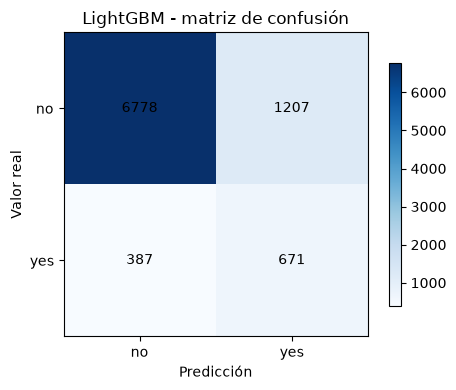

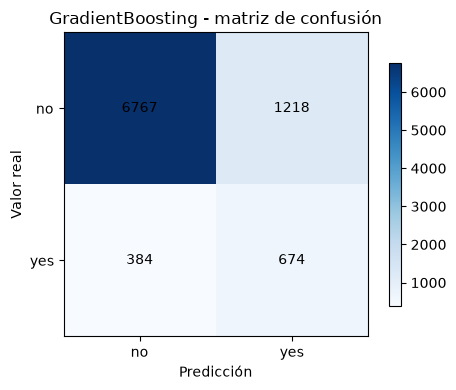

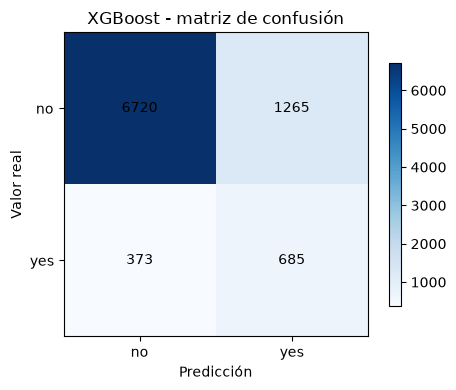

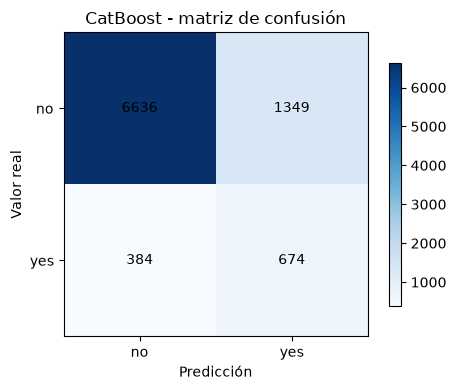

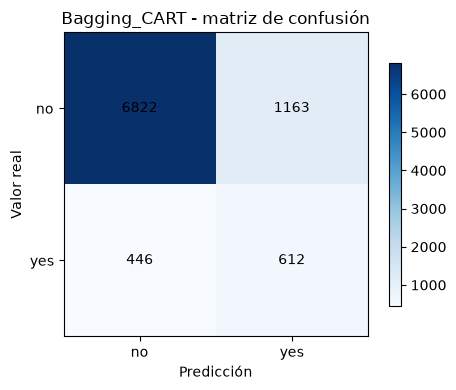

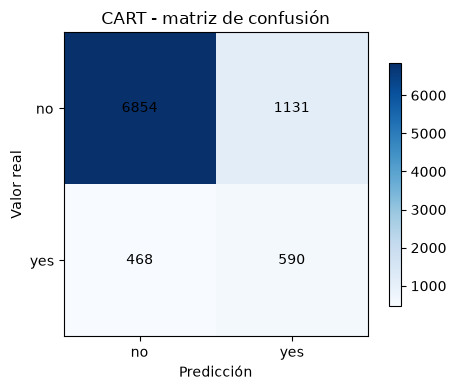

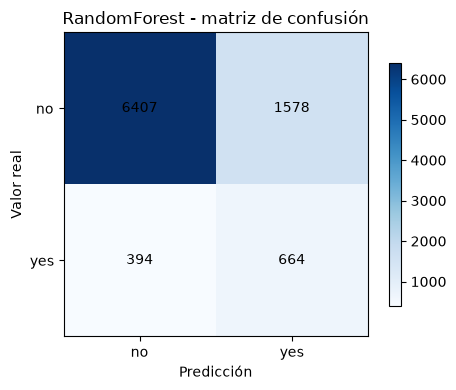

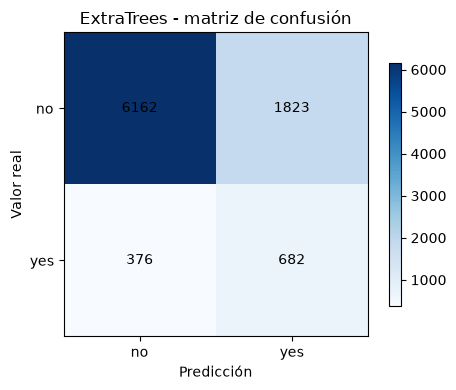

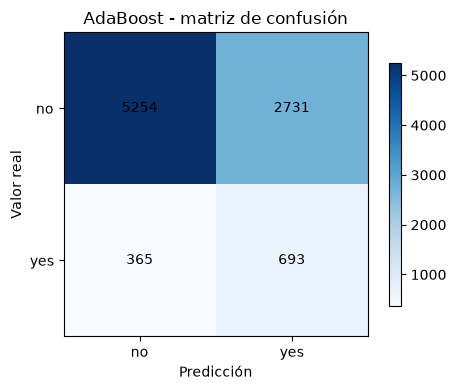

,dataset,escenario,familia_modelo,modelo,indice_configuracion,tn,fp,fn,tp,f1_positivo,roc_auc,precision_positiva,recall_positivo,accuracy
0,Bank Marketing,sin_duration,Boosting,LightGBM,48.0,6778,1207,387,671,0.457084,0.805770,0.357295,0.634216,0.823731
1,Bank Marketing,sin_duration,Boosting,GradientBoosting,17.0,6767,1218,384,674,0.456949,0.803186,0.356237,0.637051,0.822846
2,Bank Marketing,sin_duration,Boosting,XGBoost,29.0,6720,1265,373,685,0.455452,0.807038,0.351282,0.647448,0.818865
3,Bank Marketing,sin_duration,Boosting,CatBoost,65.0,6636,1349,384,674,0.437520,0.800199,0.333169,0.637051,0.808360
4,Bank Marketing,sin_duration,Bagging,Bagging_CART,5.0,6822,1163,446,612,0.432051,0.785536,0.344789,0.578450,0.822072
5,Bank Marketing,sin_duration,CART,CART,NaN,6854,1131,468,590,0.424613,0.756569,0.342824,0.557656,0.823178
6,Bank Marketing,sin_duration,Bagging,RandomForest,13.0,6407,1578,394,664,0.402424,0.785564,0.296164,0.627599,0.781931
7,Bank Marketing,sin_duration,Bagging,ExtraTrees,21.0,6162,1823,376,682,0.382823,0.778873,0.272255,0.644612,0.756828
8,Bank Marketing,sin_duration,Boosting,AdaBoost,3.0,5254,2731,365,693,0.309237,0.715430,0.202395,0.655009,0.657636


In [5]:
matrices_confusion = pd.concat(
    [
        pd.read_csv(f"{ruta_tablas}/cart_matrices_confusion.csv"),
        pd.read_csv(f"{ruta_tablas}/bagging_matrices_confusion.csv"),
        pd.read_csv(f"{ruta_tablas}/boosting_matrices_confusion.csv"),
    ],
    ignore_index=True,
    sort=False,
)

if "dataset" not in matrices_confusion.columns:
    matrices_confusion["dataset"] = "Bank Marketing"

if "escenario" not in matrices_confusion.columns:
    matrices_confusion["escenario"] = "sin_duration"

if "indice_configuracion" not in matrices_confusion.columns:
    matrices_confusion["indice_configuracion"] = np.nan

matrices_confusion["familia_modelo"] = matrices_confusion["modelo"].map({
    "CART": "CART",
    "Bagging_CART": "Bagging",
    "RandomForest": "Bagging",
    "ExtraTrees": "Bagging",
    "AdaBoost": "Boosting",
    "GradientBoosting": "Boosting",
    "XGBoost": "Boosting",
    "LightGBM": "Boosting",
    "CatBoost": "Boosting",
})

metricas_clasificacion_matrices = resultados_clasificacion[
    [
        "modelo",
        "f1_positivo",
        "roc_auc",
        "precision_positiva",
        "recall_positivo",
        "accuracy",
    ]
].copy()

matrices_confusion = matrices_confusion.merge(
    metricas_clasificacion_matrices,
    on="modelo",
    how="left",
)

columnas_matrices = [
    "dataset",
    "escenario",
    "familia_modelo",
    "modelo",
    "indice_configuracion",
    "tn",
    "fp",
    "fn",
    "tp",
    "f1_positivo",
    "roc_auc",
    "precision_positiva",
    "recall_positivo",
    "accuracy",
]

matrices_confusion = matrices_confusion[columnas_matrices]

matrices_confusion = (
    matrices_confusion
    .sort_values(["f1_positivo", "roc_auc"], ascending=[False, False])
    .reset_index(drop=True)
)

assert len(matrices_confusion) == 9
assert matrices_confusion["modelo"].nunique() == 9
assert matrices_confusion[["tn", "fp", "fn", "tp"]].notna().all().all()
assert matrices_confusion["familia_modelo"].notna().all()

for _, fila in matrices_confusion.iterrows():
    modelo_nombre = fila["modelo"]

    matriz = np.array([
        [int(fila["tn"]), int(fila["fp"])],
        [int(fila["fn"]), int(fila["tp"])],
    ])

    fig, ax = plt.subplots(figsize=(5, 4))

    imagen = ax.imshow(matriz, cmap="Blues")

    ax.set_title(f"{modelo_nombre} - matriz de confusión")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1], labels=["no", "yes"])
    ax.set_yticks([0, 1], labels=["no", "yes"])

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(
                j,
                i,
                matriz[i, j],
                ha="center",
                va="center",
                color="black",
            )

    fig.colorbar(imagen, ax=ax, shrink=0.8)
    fig.tight_layout()

    nombre_archivo = f"matriz_confusion_{modelo_nombre.lower()}.png"
    nombre_archivo = nombre_archivo.replace(" ", "_").replace("-", "_")

    fig.savefig(
        f"{ruta_figuras}/{nombre_archivo}",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

matrices_confusion

# 6. Figuras finales

En este bloque se generan las figuras comparativas principales. Para clasificación se representan el F1 positivo y el ROC-AUC, mientras que para regresión se representan el RMSE y el R².

Las figuras se ordenan de mejor a peor según la métrica correspondiente. En clasificación, valores mayores indican mejor rendimiento. En regresión, un menor RMSE indica menor error de predicción, mientras que un mayor R² indica mejor ajuste.

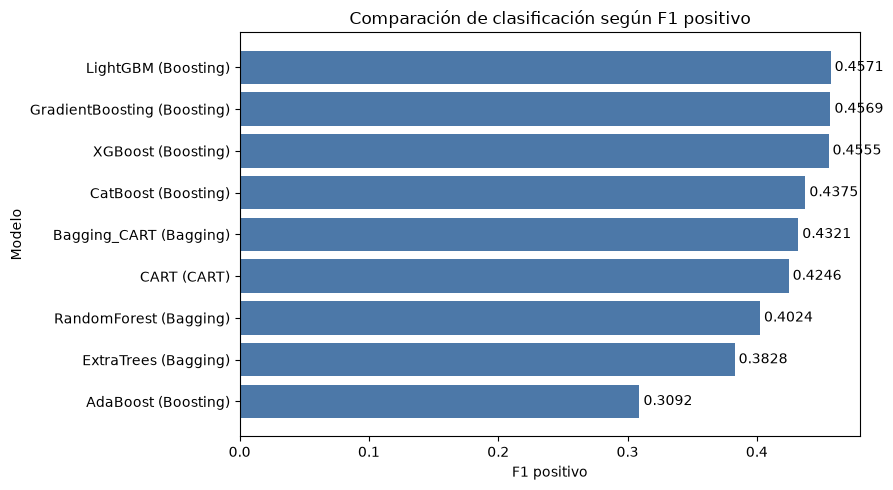

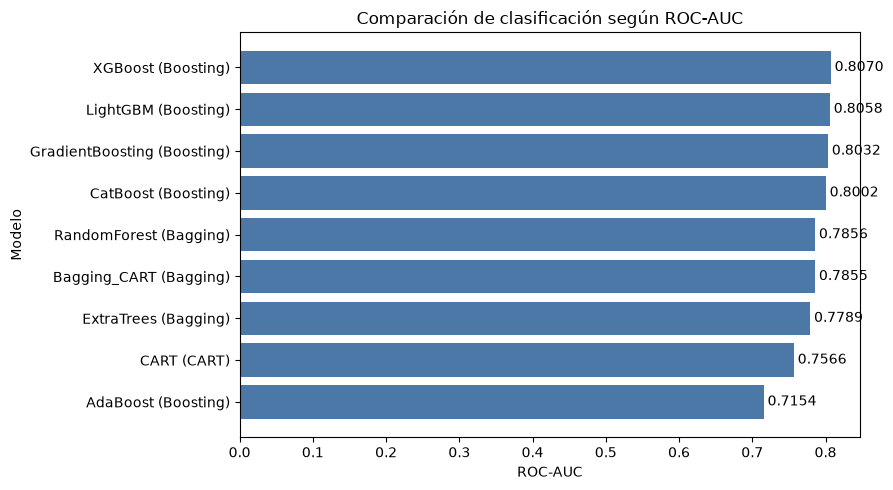

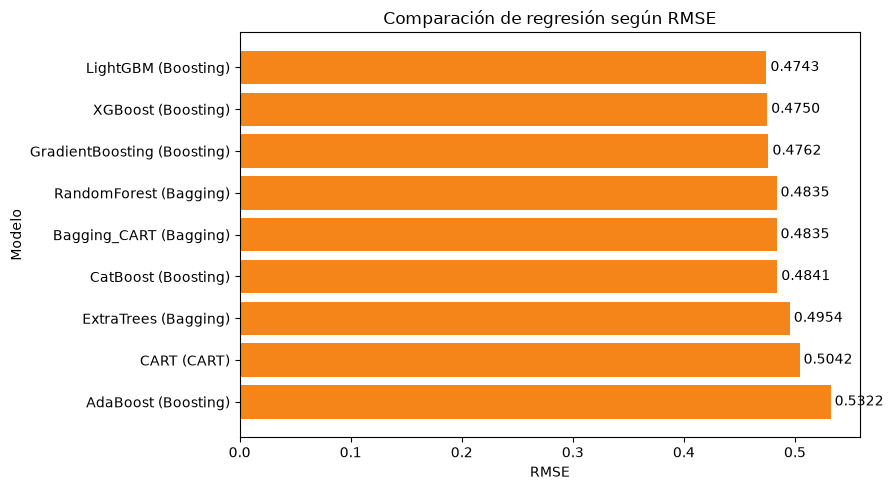

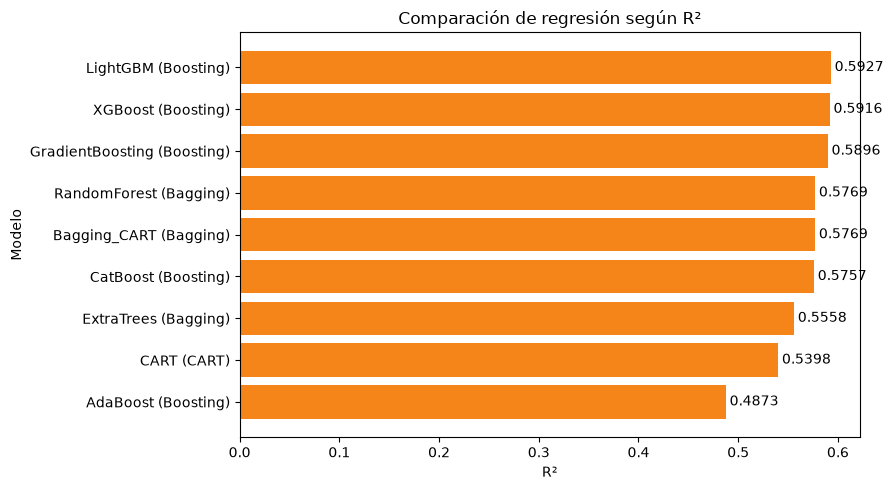

In [6]:
grafico = clasificacion_por_f1.copy()
grafico["etiqueta"] = grafico["modelo"] + " (" + grafico["familia_modelo"] + ")"
grafico = grafico.sort_values("f1_positivo", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(grafico["etiqueta"], grafico["f1_positivo"], color="#4c78a8")
ax.set_title("Comparación de clasificación según F1 positivo")
ax.set_xlabel("F1 positivo")
ax.set_ylabel("Modelo")

for i, valor in enumerate(grafico["f1_positivo"]):
    ax.text(
        valor,
        i,
        f" {valor:.4f}",
        va="center",
    )

fig.tight_layout()

ruta_figura = f"{ruta_figuras}/comparacion_clasificacion_f1.png"
fig.savefig(ruta_figura, dpi=150, bbox_inches="tight")

plt.show()

grafico = clasificacion_por_roc.copy()
grafico["etiqueta"] = grafico["modelo"] + " (" + grafico["familia_modelo"] + ")"
grafico = grafico.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(grafico["etiqueta"], grafico["roc_auc"], color="#4c78a8")
ax.set_title("Comparación de clasificación según ROC-AUC")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Modelo")

for i, valor in enumerate(grafico["roc_auc"]):
    ax.text(
        valor,
        i,
        f" {valor:.4f}",
        va="center",
    )

fig.tight_layout()

ruta_figura = f"{ruta_figuras}/comparacion_clasificacion_roc_auc.png"
fig.savefig(ruta_figura, dpi=150, bbox_inches="tight")

plt.show()

grafico = regresion_por_rmse.copy()
grafico["etiqueta"] = grafico["modelo"] + " (" + grafico["familia_modelo"] + ")"
grafico = grafico.sort_values("rmse", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(grafico["etiqueta"], grafico["rmse"], color="#f58518")
ax.set_title("Comparación de regresión según RMSE")
ax.set_xlabel("RMSE")
ax.set_ylabel("Modelo")

for i, valor in enumerate(grafico["rmse"]):
    ax.text(
        valor,
        i,
        f" {valor:.4f}",
        va="center",
    )

fig.tight_layout()

ruta_figura = f"{ruta_figuras}/comparacion_regresion_rmse.png"
fig.savefig(ruta_figura, dpi=150, bbox_inches="tight")

plt.show()

grafico = regresion_por_r2.copy()
grafico["etiqueta"] = grafico["modelo"] + " (" + grafico["familia_modelo"] + ")"
grafico = grafico.sort_values("r2", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(grafico["etiqueta"], grafico["r2"], color="#f58518")
ax.set_title("Comparación de regresión según R²")
ax.set_xlabel("R²")
ax.set_ylabel("Modelo")

for i, valor in enumerate(grafico["r2"]):
    ax.text(
        valor,
        i,
        f" {valor:.4f}",
        va="center",
    )

fig.tight_layout()

ruta_figura = f"{ruta_figuras}/comparacion_regresion_r2.png"
fig.savefig(ruta_figura, dpi=150, bbox_inches="tight")

plt.show()

# 7. Guardado de resultados finales

En este bloque se guardan las tablas finales generadas en el cuaderno de comparación. Además de conservar los resultados completos, se crean tablas resumidas y redondeadas para facilitar su uso posterior en la redacción del TFG.

Las tablas completas mantienen toda la información técnica, mientras que las tablas resumidas contienen únicamente las métricas principales y complementarias necesarias para comentar los resultados.

In [7]:
tabla_resumen_clasificacion_tfg = (
    resultados_clasificacion[
        [
            "familia_modelo",
            "modelo",
            "f1_positivo",
            "precision_positiva",
            "recall_positivo",
            "roc_auc",
            "accuracy",
            "parametros",
        ]
    ]
    .sort_values(["f1_positivo", "roc_auc"], ascending=[False, False])
    .reset_index(drop=True)
)

tabla_resumen_regresion_tfg = (
    resultados_regresion[
        [
            "familia_modelo",
            "modelo",
            "rmse",
            "mae",
            "mse",
            "r2",
            "parametros",
        ]
    ]
    .sort_values(["rmse", "r2"], ascending=[True, False])
    .reset_index(drop=True)
)

columnas_numericas_clasificacion = [
    "f1_positivo",
    "precision_positiva",
    "recall_positivo",
    "roc_auc",
    "accuracy",
]

columnas_numericas_regresion = [
    "rmse",
    "mae",
    "mse",
    "r2",
]

tabla_resumen_clasificacion_tfg[columnas_numericas_clasificacion] = (
    tabla_resumen_clasificacion_tfg[columnas_numericas_clasificacion]
    .round(4)
)

tabla_resumen_regresion_tfg[columnas_numericas_regresion] = (
    tabla_resumen_regresion_tfg[columnas_numericas_regresion]
    .round(4)
)

ranking_final_tfg = ranking_final.copy()

columnas_numericas_ranking = [
    "f1_positivo",
    "roc_auc",
    "precision_positiva",
    "recall_positivo",
    "accuracy",
    "rmse",
    "mae",
    "mse",
    "r2",
]

ranking_final_tfg[columnas_numericas_ranking] = (
    ranking_final_tfg[columnas_numericas_ranking]
    .round(4)
)

resultados_clasificacion.to_csv(
    f"{ruta_tablas}/comparacion_clasificacion_metricas.csv",
    index=False,
)

resultados_regresion.to_csv(
    f"{ruta_tablas}/comparacion_regresion_metricas.csv",
    index=False,
)

clasificacion_por_f1.to_csv(
    f"{ruta_tablas}/comparacion_clasificacion_ranking_f1.csv",
    index=False,
)

clasificacion_por_roc.to_csv(
    f"{ruta_tablas}/comparacion_clasificacion_ranking_roc_auc.csv",
    index=False,
)

regresion_por_rmse.to_csv(
    f"{ruta_tablas}/comparacion_regresion_ranking_rmse.csv",
    index=False,
)

regresion_por_r2.to_csv(
    f"{ruta_tablas}/comparacion_regresion_ranking_r2.csv",
    index=False,
)

ranking_final.to_csv(
    f"{ruta_tablas}/ranking_final_modelos.csv",
    index=False,
)

ranking_final_tfg.to_csv(
    f"{ruta_tablas}/ranking_final_modelos_tfg.csv",
    index=False,
)

busqueda_hiperparametros.to_csv(
    f"{ruta_tablas}/comparacion_busqueda_hiperparametros.csv",
    index=False,
)

resumen_validacion.to_csv(
    f"{ruta_tablas}/comparacion_resumen_validacion.csv",
    index=False,
)

matrices_confusion.to_csv(
    f"{ruta_tablas}/comparacion_matrices_confusion.csv",
    index=False,
)

tabla_resumen_clasificacion_tfg.to_csv(
    f"{ruta_tablas}/tabla_resumen_clasificacion_tfg.csv",
    index=False,
)

tabla_resumen_regresion_tfg.to_csv(
    f"{ruta_tablas}/tabla_resumen_regresion_tfg.csv",
    index=False,
)